# Benchmark: meshio++ vs legacy meshio

Times read/write conversions on the formats supported by **both** the
original pure-Python `meshio` and the C++-accelerated `meshioplusplus`
(meshio++). Identical `Mesh`/`read`/`write` APIs, same in-memory mesh.

The headline input is the bundled **`example.msh`** — a real Gmsh mesh of a
mechanical bracket (~52k nodes, ~293k cells, mixed triangles + tetrahedra).
A synthetic tetrahedral cube and a **size-scaling sweep** complete the
picture. The legacy `meshio` is pure Python, imported from source (no
build); meshio++ is the installed package. See `bench.py`.

**What to expect.** meshio++'s wins are largest where pure-Python parsing
is the bottleneck — **text/ASCII** formats. Plain binary dumps are already
at numpy C-speed in pure-Python meshio, so there the gains are small or,
for the simplest layouts, slightly negative (the pybind11 boundary isn't
free). HDF5 formats share the same HDF5 C library either way. The relative
speedup is roughly size-independent once the mesh is non-trivial, but for
text formats it *climbs with size* out of the small-mesh regime (fixed
per-call overheads amortise), so large meshes get the full speedup.

In [1]:
import os
import platform
import tempfile

import numpy as np
import matplotlib.pyplot as plt

import bench
import inputs

REPEATS = 5
PLOTS_LOCAL = os.path.join(os.getcwd(), 'plots')
PLOTS_DOC = os.path.normpath(
    os.path.join(os.getcwd(), '..', 'doc', 'public', 'benchmarks'))
os.makedirs(PLOTS_LOCAL, exist_ok=True)
os.makedirs(PLOTS_DOC, exist_ok=True)

def savefig(fig, stem, doc=True):
    dirs = [PLOTS_LOCAL] + ([PLOTS_DOC] if doc else [])
    for d in dirs:
        fig.savefig(os.path.join(d, stem + '.svg'))
        fig.savefig(os.path.join(d, stem + '.png'), dpi=110)

print('meshio++     :', bench.PP_VERSION)
print('legacy meshio:', bench.LEGACY_VERSION)
print('python       :', platform.python_version())
print('platform     :', platform.platform())
print('processor    :', platform.processor() or 'n/a', '|', os.cpu_count(), 'cpus')

meshio++     : 6.0.0
legacy meshio: 5.3.5
python       : 3.12.10
platform     : Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
processor    : x86_64 | 20 cpus


## Inputs

* **bracket** — the bundled `example.msh` geometry (real CAD mesh, mixed
  triangles + tetrahedra). *This is the headline result.*
* **cube** — a numpy-generated structured tetrahedral mesh (single cell
  type, larger), the synthetic control.

In [2]:
meshes = {}
pts, cells = inputs.example_geometry()
meshes['bracket'] = (pts, cells)
print(f"bracket : {len(pts):,} pts, {sum(len(c[1]) for c in cells):,} cells (from example.msh)")

pts, cells = inputs.synthetic_tet_grid(56)
meshes['cube'] = (pts, cells)
print(f"cube    : {len(pts):,} pts, {sum(len(c[1]) for c in cells):,} tets (synthetic)")

bracket : 52,282 pts, 293,408 cells (from example.msh)
cube    : 175,616 pts, 998,250 tets (synthetic)


## Run the benchmark

In [3]:
all_records = {}
for name, (pts, cells) in meshes.items():
    print(f'\n=== {name} ===')
    recs = bench.run(pts, cells, repeats=REPEATS)
    for r in recs:
        r['mesh'] = name
    all_records[name] = recs

flat = [r for recs in all_records.values() for r in recs]
bench.write_csv(flat, 'results.csv')
print('\nwrote results.csv (%d rows)' % len(flat))


=== bracket ===


  vtu (binary+zlib)    write   620.9->   52.7 ms (11.8x)  read    61.6->   22.6 ms ( 2.7x)


Warning: VTU ASCII files are only meant for debugging.

Warning: VTU ASCII files are only meant for debugging.

Warning: VTU ASCII files are only meant for debugging.

...

  vtk (binary)         write    63.3->   58.0 ms ( 1.1x)  read    36.8->   55.2 ms ( 0.7x)


  gmsh (binary)        write    88.1->   60.7 ms ( 1.5x)  read    39.9->   54.0 ms ( 0.7x)


  xdmf (HDF5)          write   142.9->  156.4 ms ( 0.9x)  read    62.7->   63.1 ms ( 1.0x)


  med (HDF5)           write    47.6->   63.7 ms ( 0.7x)  read    23.2->   24.5 ms ( 0.9x)


  mdpa                 write  2761.4-> 2040.0 ms ( 1.4x)  read  2692.3-> 3173.7 ms ( 0.8x)

wrote results.csv (13 rows)


## Plot helpers

In [4]:
def plot_times(recs, title, stem, doc=True):
    labels = [r['format'] for r in recs]
    y = np.arange(len(labels))
    h = 0.38
    fig, axes = plt.subplots(1, 2, figsize=(12, 0.6 * len(labels) + 1.6),
                             sharey=True)
    for ax, op in zip(axes, ['write', 'read']):
        lg = [r[f'{op}_legacy'] * 1e3 for r in recs]
        pp = [r[f'{op}_pp'] * 1e3 for r in recs]
        ax.barh(y + h / 2, lg, height=h, label='meshio (Python)', color='#b0b7c3')
        ax.barh(y - h / 2, pp, height=h, label='meshio++', color='#2ec4b6')
        ax.set_xscale('log')
        ax.set_xlabel(f'{op} time (ms, log)')
        ax.set_yticks(y)
        ax.set_yticklabels(labels)
        ax.invert_yaxis()
        ax.grid(axis='x', which='both', alpha=0.25)
    axes[0].legend(loc='lower right', fontsize=9)
    fig.suptitle(title)
    fig.tight_layout()
    savefig(fig, stem, doc=doc)
    plt.show()


def plot_speedup(recs, title, stem, doc=True):
    labels = [r['format'] for r in recs]
    y = np.arange(len(labels))
    h = 0.38
    ws = [r['write_speedup'] for r in recs]
    rs = [r['read_speedup'] for r in recs]
    fig, ax = plt.subplots(figsize=(9, 0.6 * len(labels) + 1.8))
    xmax = max(max(ws), max(rs)) * 1.35
    xmin = min(min(ws), min(rs)) / 1.35
    ax.axvspan(1.0, xmax, color='#2ec4b6', alpha=0.08)
    b1 = ax.barh(y + h / 2, ws, height=h, label='write', color='#1f4e79')
    b2 = ax.barh(y - h / 2, rs, height=h, label='read', color='#2ec4b6')
    for bars in (b1, b2):
        for bar in bars:
            w = bar.get_width()
            ax.text(w * 1.03, bar.get_y() + bar.get_height() / 2,
                    f'{w:.1f}x', va='center', fontsize=8)
    ax.axvline(1.0, color='#333', lw=1, ls='--')
    ax.set_xscale('log')
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel('speedup = legacy / meshio++  (log; shaded = meshio++ faster)')
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.legend(loc='lower right', fontsize=9)
    ax.set_title(title)
    fig.tight_layout()
    savefig(fig, stem, doc=doc)
    plt.show()

## Real mesh (`example.msh`) — timings

Read/write time (log scale), pure-Python meshio vs meshio++, on the actual
bracket mesh.

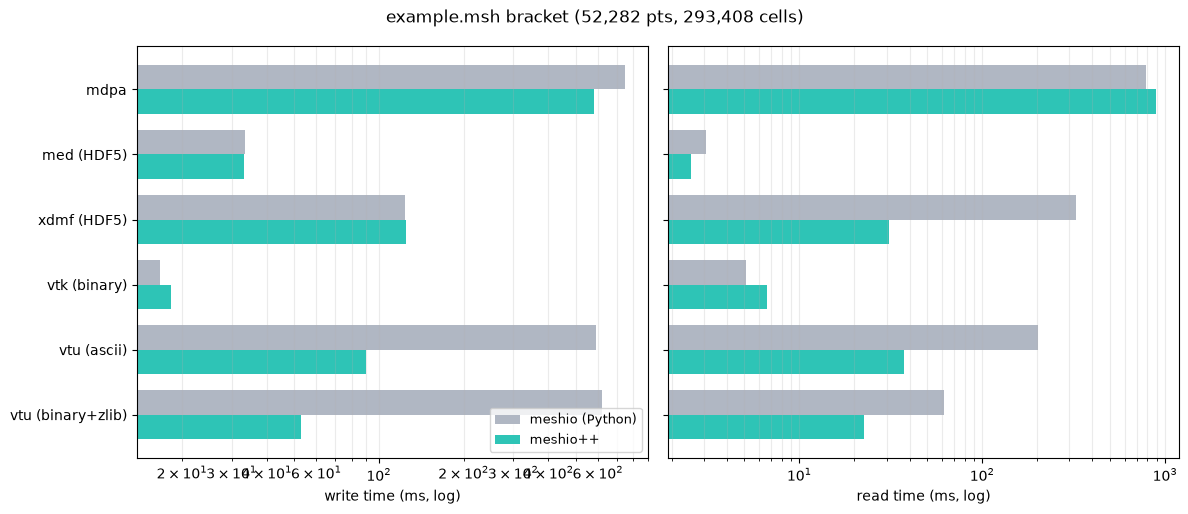

In [5]:
plot_times(all_records['bracket'],
           f"example.msh bracket ({len(meshes['bracket'][0]):,} pts, "
           f"{sum(len(c[1]) for c in meshes['bracket'][1]):,} cells)",
           'benchmark_times')

## Real mesh (`example.msh`) — speedup

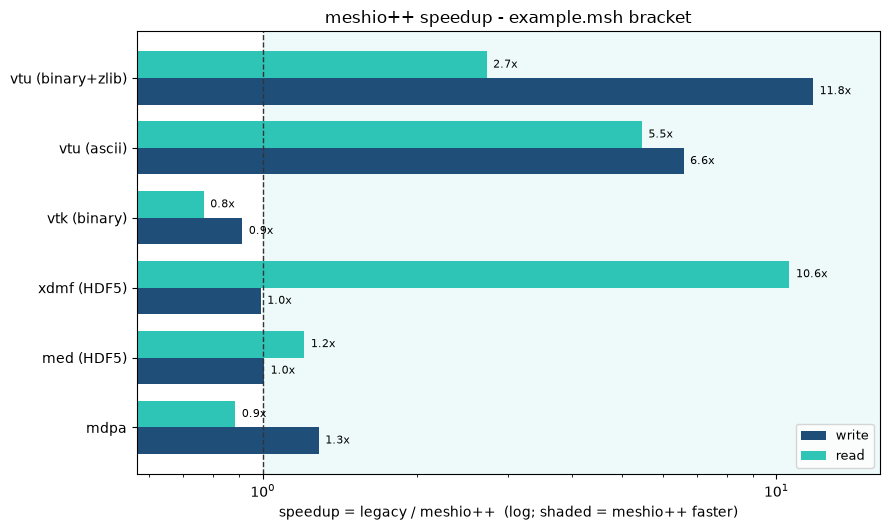

In [6]:
plot_speedup(all_records['bracket'], 'meshio++ speedup - example.msh bracket',
             'benchmark_speedup')

## Synthetic cube (control)

A single-cell-type tetrahedral mesh, kept for comparison. It adds
single-type Gmsh binary (which the mixed bracket can't use without extra
tags).

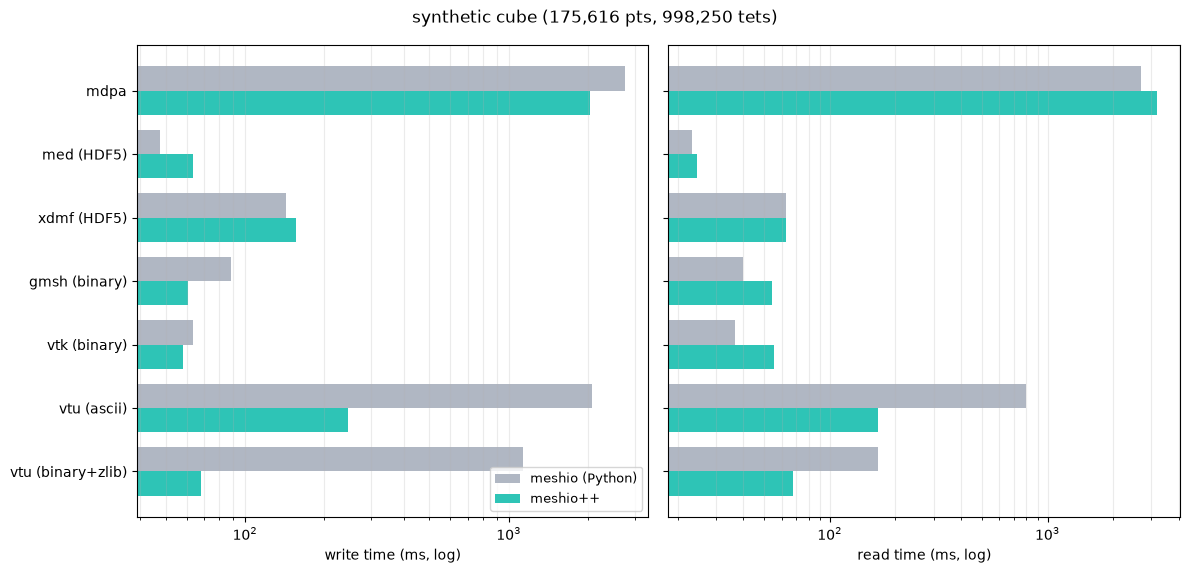

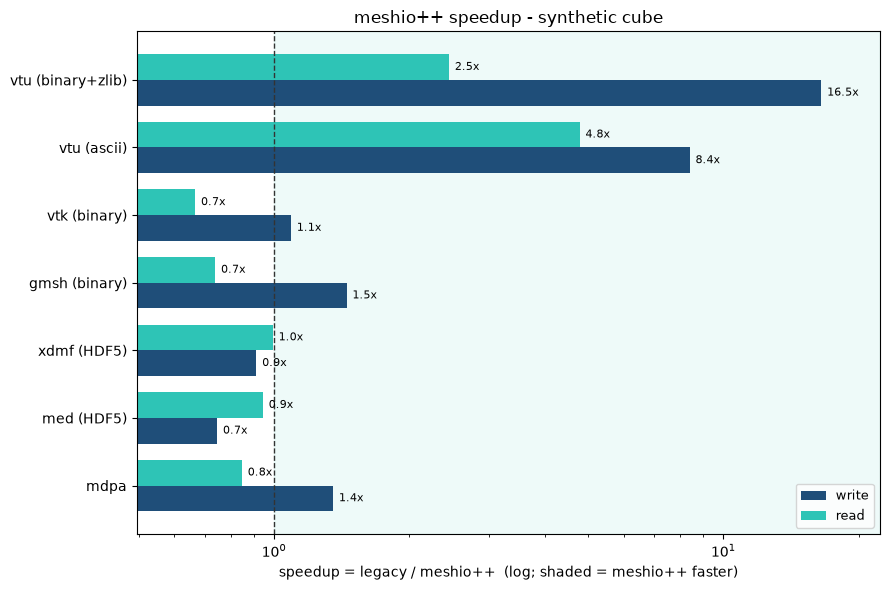

In [7]:
plot_times(all_records['cube'],
           f"synthetic cube ({len(meshes['cube'][0]):,} pts, "
           f"{len(meshes['cube'][1][0][1]):,} tets)",
           'benchmark_times_cube', doc=False)
plot_speedup(all_records['cube'], 'meshio++ speedup - synthetic cube',
             'benchmark_speedup_cube', doc=False)

## Does the speedup grow with mesh size?

Sweep synthetic tetrahedral meshes from tiny to large and track the
speedup for three representative formats. The relative speedup is roughly
*size-independent* once the mesh is non-trivial (both libraries are O(n)),
but for **VTU ASCII write** it climbs out of the small-mesh regime as the
fixed per-call overheads amortise — so a large real mesh gets the full
speedup, while a tiny one does not.

In [8]:
SCALING_SIZES = [4, 6, 9, 14, 20, 30, 44, 56]
SCALING_FORMATS = [
    ('vtu (ascii)', 'mesh_ascii.vtu', dict(binary=False), None, True),
    ('vtu (binary+zlib)', 'mesh.vtu', dict(binary=True), None, True),
    ('vtk (binary)', 'mesh.vtk', dict(binary=True), None, True),
]

scaling = {f[0]: {'n': [], 'write': [], 'read': []} for f in SCALING_FORMATS}
for size in SCALING_SIZES:
    pts, cells = inputs.synthetic_tet_grid(size)
    ncells = len(cells[0][1])
    with tempfile.TemporaryDirectory() as tmp:
        for spec in SCALING_FORMATS:
            rec = bench.bench_one(pts, cells, spec, tmp, repeats=3)
            if rec is None:
                continue
            s = scaling[spec[0]]
            s['n'].append(ncells)
            s['write'].append(rec['write_speedup'])
            s['read'].append(rec['read_speedup'])
    print(f'  n={size:3d}  {ncells:>9,} cells  done')

Warning: VTU ASCII files are only meant for debugging.

Warning: VTU ASCII files are only meant for debugging.

Warning: VTU ASCII files are only meant for debugging.

Warning: VTU ASCII files are only meant for debugging.

Warning: VTU ASCII files are only meant for debugging.

...

Warning: VTU ASCII files are only meant for debugging.

Warning: VTU ASCII files are only meant for debugging.

Warning: VTU ASCII files are only meant for debugging.

Warning: VTU ASCII files are only meant for debugging.

  n= 56    998,250 cells  done


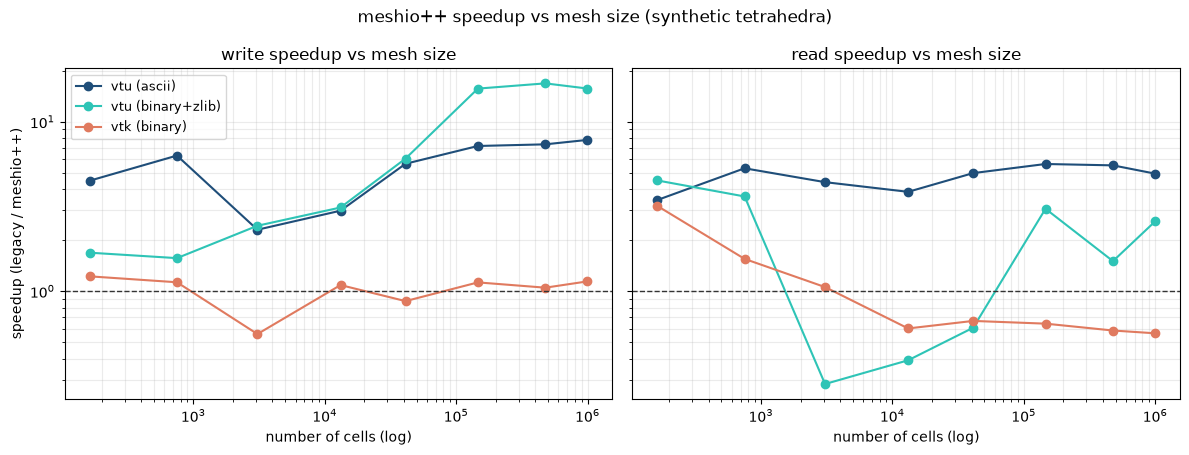

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
colors = {'vtu (ascii)': '#1f4e79', 'vtu (binary+zlib)': '#2ec4b6',
          'vtk (binary)': '#e07a5f'}
for ax, op in zip(axes, ['write', 'read']):
    for fmt, s in scaling.items():
        ax.plot(s['n'], s[op], 'o-', color=colors[fmt], label=fmt)
    ax.axhline(1.0, color='#333', lw=1, ls='--')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('number of cells (log)')
    ax.set_title(f'{op} speedup vs mesh size')
    ax.grid(which='both', alpha=0.25)
axes[0].set_ylabel('speedup (legacy / meshio++)')
axes[0].legend(fontsize=9)
fig.suptitle('meshio++ speedup vs mesh size (synthetic tetrahedra)')
fig.tight_layout()
savefig(fig, 'benchmark_scaling')
plt.show()

## Summary table

In [10]:
hdr = f"{'mesh':8s} {'format':20s} {'write x':>8s} {'read x':>8s} {'MB':>7s}"
print(hdr)
print('-' * len(hdr))
for name, recs in all_records.items():
    for r in recs:
        print(f"{name:8s} {r['format']:20s} "
              f"{r['write_speedup']:7.1f}x {r['read_speedup']:7.1f}x "
              f"{r['bytes']/1e6:6.2f}")

mesh     format                write x   read x      MB
-------------------------------------------------------
bracket  vtu (binary+zlib)       11.8x     2.7x   4.77
bracket  vtu (ascii)              6.6x     5.5x  12.31
bracket  vtk (binary)             0.9x     0.8x  13.70
bracket  xdmf (HDF5)              1.0x    10.6x   3.45
bracket  med (HDF5)               1.0x     1.2x  10.19
bracket  mdpa                     1.3x     0.9x  13.69
cube     vtu (binary+zlib)       16.5x     2.5x   7.15
cube     vtu (ascii)              8.4x     4.8x  45.65
cube     vtk (binary)             1.1x     0.7x  48.14
cube     gmsh (binary)            1.5x     0.7x  45.55
cube     xdmf (HDF5)              0.9x     1.0x   3.92
cube     med (HDF5)               0.7x     0.9x  36.17
cube     mdpa                     1.4x     0.8x  49.75


**Takeaway.** On the real `example.msh` bracket, meshio++ is several times
faster for text formats (VTU ASCII) and mixed-topology XDMF reads, roughly
even on HDF5, and no faster on plain binary dumps that pure-Python meshio
already streams through numpy. The scaling sweep confirms the effect is
per-element (constant ratio) once past the tiny-mesh regime — large meshes
realise the full speedup. Numbers are single-machine and indicative;
re-run this notebook to reproduce on your hardware.